In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import xarray as xr

In [2]:
dust_df = pd.read_csv("DATA/processed/3_dust_points_vars_2026-04-24.csv")
# control_df = pd.read_csv("DATA/processed/5_control_grid_2026-04-21.csv")
control_ds = xr.open_dataset("DATA/processed/5_control_grid_2026-05-06.nc")

In [3]:
control_ds

<xarray.Dataset> Size: 410MB
Dimensions:              (time: 7307, lon: 103, lat: 68)
Coordinates:
  * time                 (time) datetime64[ns] 58kB 2000-12-31 ... 2021-01-01
  * lon                  (lon) float64 824B -124.8 -124.6 ... -100.6 -100.3
  * lat                  (lat) float64 544B 27.62 27.86 28.1 ... 43.46 43.7
    spatial_ref          int64 8B ...
Data variables:
    SoilMoi00_10cm_tavg  (time, lat, lon) float32 205MB ...
    wind_speed           (time, lat, lon) float32 205MB ...
    usage                (lat, lon) float64 56kB ...
    soil_texture         (lat, lon) float32 28kB ...
    soil_order           (lat, lon) float64 56kB ...

Create a side-by-side bar chart comparing:
- frequency of soil textures at dust points
- frequency of soil textures in the full soil raster

In [4]:
texture_dict = {
    1: "Sand",
    2: "Loamy Sand",
    3: "Sandy Loam",
    4: "Silt Loam",
    5: "Silt",
    6: "Loam",
    7: "Sandy Clay Loam",
    8: "Silty Clay Loam",
    9: "Clay Loam", 
    10: "Sandy Clay",
    11: "Silty Clay",
    12: "Clay", 
    13: "Organic Matter",
    14: "Water", 
    15: "Bedrock",
    16: "Other",
}

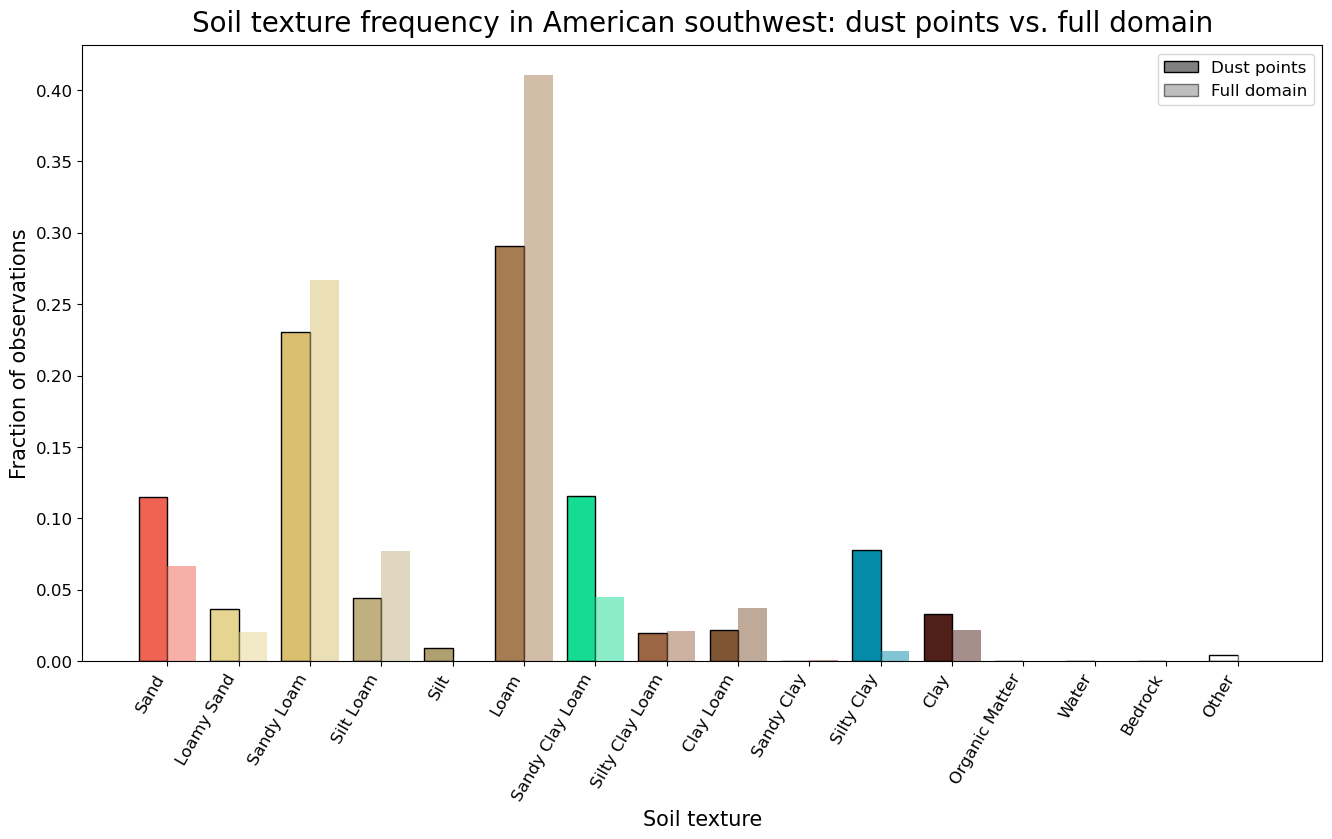

In [5]:
#--- Calculate bins
dust_counts = {k: np.sum(dust_df['texture'] == k) for k in texture_dict.keys()}
dust_total = sum(dust_counts.values())
dust_fraction = {k: v / dust_total for k, v in dust_counts.items()}

non_dust_counts = {k: np.sum(control_ds['soil_texture'] == k) for k in texture_dict.keys()}
non_dust_total = sum(non_dust_counts.values())
non_dust_fraction = {k: v / non_dust_total for k, v in non_dust_counts.items()}

texture_colors = [
    "#EE6352",  # Sand
    "#e6d591",  # Loamy Sand
    "#d9c070",  # Sandy Loam
    "#c0b080",  # Silt Loam
    "#b0a070",  # Silt
    "#a67c52",  # Loam
    "#16DB93",  # Sandy Clay Loam
    "#9c6644",  # Silty Clay Loam
    "#805533",  # Clay Loam
    "#8c3f2f",  # Sandy Clay
    "#048BA8",  # Silty Clay
    "#4f1f18",  # Clay
    "#1a1a1a",  # Organic Matter
    "#3399ff",  # Water
    "#808080",  # Bedrock
    "#ffffff",  # Other
]

# Prepare for plotting
categories = list(texture_dict.keys())
labels = [texture_dict[k] for k in categories]
x = np.arange(len(categories))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 8))

# Plot bars
for i, k in enumerate(categories):
    color = texture_colors[i]
    ax.bar(x[i] - width / 2, dust_fraction[k], width, color=color, edgecolor="black", label="Dust points" if i == 0 else "")
    ax.bar(x[i] + width / 2, non_dust_fraction[k], width, color=color, alpha=0.5, label="Full domain" if i == 0 else "")

# Labels and ticks
ax.tick_params(labelsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlabel("Soil texture", fontsize=15)
ax.set_title(f"Soil texture frequency in American southwest: dust points vs. full domain", fontsize=20, pad=10)

# Legend
legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/3_texture_1_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [6]:
def add_medians_to_plot(ax_bar, median_dust, median_control):

    ax_bar.axvline(
        median_dust,
        color="tab:orange",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    ax_bar.text(x=median_dust, 
                y=0.84,
                s=f'Median: {median_dust:.2f}', 
                color="tab:orange",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())

    ax_bar.axvline(
        median_control,
        color="tab:blue",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    
    ax_bar.text(x=median_control, 
                y=0.84,
                s=f'Median: {median_control:.2f}', 
                color="tab:blue",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())
    
    return

Plotting wind speed bar chart...


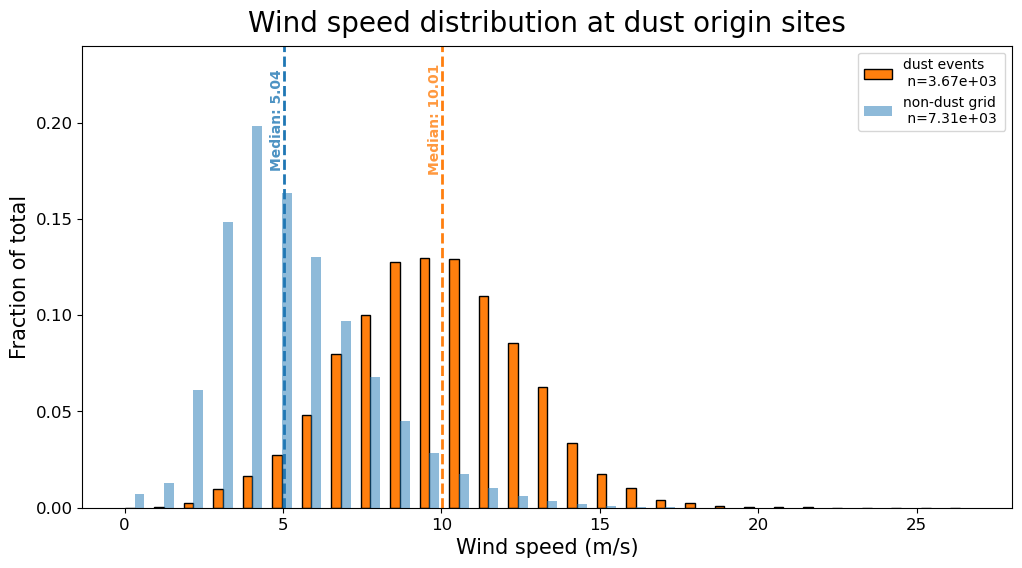

In [7]:
print("Plotting wind speed bar chart...")

#--- Calculate bins
bins = np.linspace(0, 27, 30)
counts_dust, _ = np.histogram(dust_df["wind_speed"], bins=bins)
counts_non_dust, _ = np.histogram(control_ds["wind_speed"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust = counts_dust / np.sum(counts_dust)
density_non_dust = counts_non_dust / np.sum(counts_non_dust)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust events \n n={len(dust_df["wind_speed"]) :.2e}",)
plt.bar(bins[:-1] + width, density_non_dust, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"non-dust grid \n n={len(control_ds["wind_speed"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["wind_speed"].median(skipna=True)
median_control = control_ds["wind_speed"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.24)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Wind speed (m/s)", fontsize=15)
ax_bar.set_title("Wind speed distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/1_wind_speed_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

Plotting moisture bar chart...


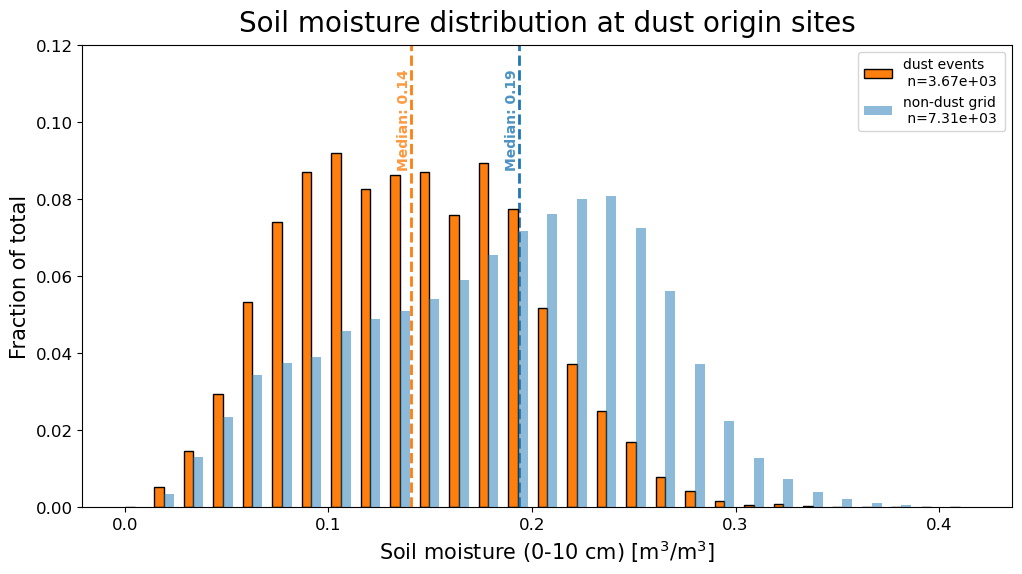

In [8]:
print("Plotting moisture bar chart...")

#--- Calculate bins
bins = np.linspace(0, 0.42, 30)
counts_dust, _ = np.histogram(dust_df["moisture"], bins=bins)
counts_non_dust, _ = np.histogram(control_ds["SoilMoi00_10cm_tavg"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust = counts_dust / np.sum(counts_dust)
density_non_dust = counts_non_dust / np.sum(counts_non_dust)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust events \n n={len(dust_df["moisture"]) :.2e}",)
plt.bar(bins[:-1] + width, density_non_dust, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"non-dust grid \n n={len(control_ds["SoilMoi00_10cm_tavg"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["moisture"].median(skipna=True)
median_control = control_ds["SoilMoi00_10cm_tavg"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.12)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Soil moisture (0-10 cm) [m$^3$/m$^3$]", fontsize=15)
ax_bar.set_title("Soil moisture distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/2_soil_moisture_0_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()